1. 正在计算真实 3x+1 序列步数...
   计算完成！耗时: 0.578 秒

2. 正在计算抛物线沙盒的暂态坍缩步数...
   计算完成！耗时: 0.295 秒

3. 正在生成长尾分布对比图...
🎉 绝美长尾对比图已生成，保存至: stopping_time_comparison.png


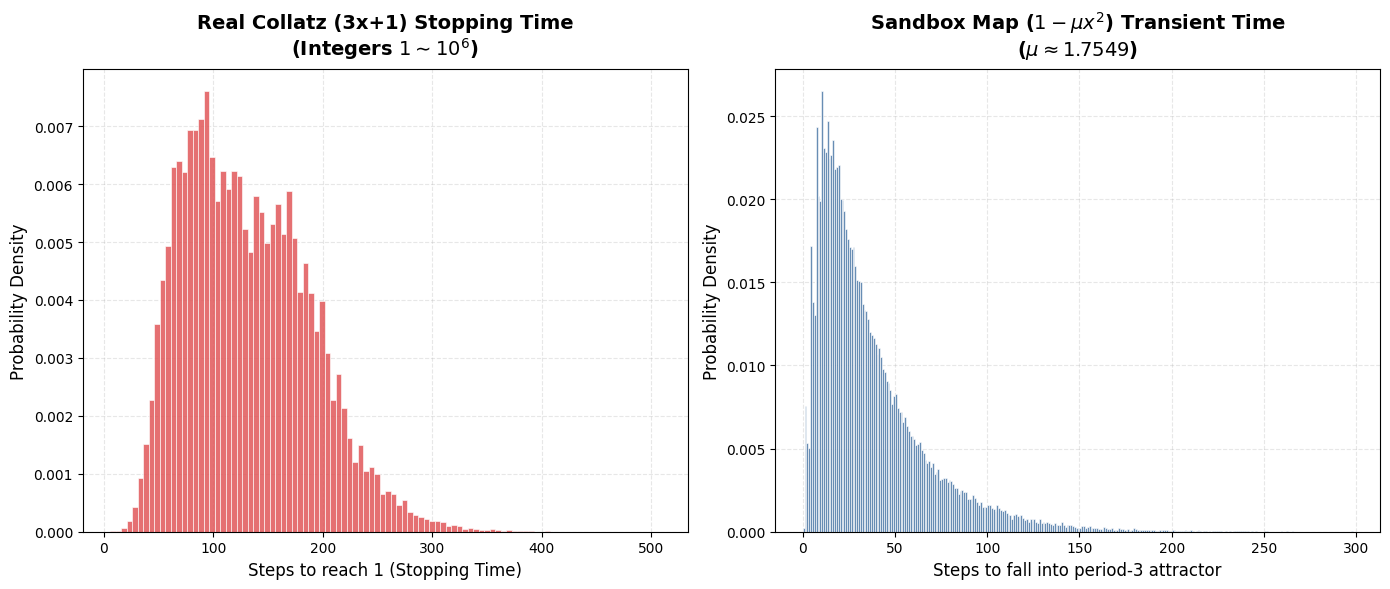

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import time

# ==========================================
# 1. 真实的 3x+1 (Collatz) 停时分布
# ==========================================
N_collatz = 100000
# 在 1 到 100万 之间随机撒 10万个整数作为初始测试点
# 使用 int64 防止迭代过程中溢出
real_ints = np.random.randint(1, 1000000, size=N_collatz, dtype=np.int64)

# 使用 Numba 进行 C 级别加速
@njit
def calc_collatz_steps(nums):
    res = np.zeros(len(nums), dtype=np.int32)
    for i in range(len(nums)):
        n = nums[i]
        steps = 0
        while n > 1:
            if n % 2 == 0:
                n = n // 2
            else:
                n = 3 * n + 1
            steps += 1
        res[i] = steps
    return res

print("1. 正在计算真实 3x+1 序列步数...")
t0 = time.time()
collatz_steps = calc_collatz_steps(real_ints)
print(f"   计算完成！耗时: {time.time() - t0:.3f} 秒\n")

# ==========================================
# 2. 沙盒的抛物线 (1 - mu*x^2) 坍缩步数分布
# ==========================================
roots = np.roots([1, -2, 1, -1])
mu = np.real(roots[np.isreal(roots)])[0]

N_samples = 100000
max_steps_sandbox = 300
eps = 1e-4
targets = np.array([0.0, 1.0, 1.0 - mu])

sandbox_steps = np.zeros(N_samples)
x = np.random.uniform(-1, 1, N_samples)
active = np.ones(N_samples, dtype=bool)

print("2. 正在计算抛物线沙盒的暂态坍缩步数...")
t1 = time.time()
for i in range(max_steps_sandbox):
    if not np.any(active):
        break
    
    # 检查是否掉进三周期吸收盆
    d0 = np.abs(x[active] - targets[0]) < eps
    d1 = np.abs(x[active] - targets[1]) < eps
    d2 = np.abs(x[active] - targets[2]) < eps
    converged = d0 | d1 | d2
    
    active_indices = np.where(active)[0]
    sandbox_steps[active_indices[converged]] = i
    active[active_indices[converged]] = False
    
    # 存活的粒子继续迭代
    x[active] = 1.0 - mu * x[active]**2

# 剔除未在规定步数内收敛的极少数极值点
valid_sandbox = sandbox_steps[sandbox_steps < max_steps_sandbox]
print(f"   计算完成！耗时: {time.time() - t1:.3f} 秒\n")

# ==========================================
# 3. 顶级学术质感绘图对比
# ==========================================
print("3. 正在生成长尾分布对比图...")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 图 1：真实 3x+1
axes[0].hist(collatz_steps, bins=100, density=True, color="#E15759", alpha=0.85, edgecolor="white", linewidth=0.5)
# 修复转义报错：使用 r"" 并在分行时拆分字符串
axes[0].set_title(r"Real Collatz (3x+1) Stopping Time" "\n" r"(Integers $1 \sim 10^6$)", 
                  fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel("Steps to reach 1 (Stopping Time)", fontsize=12)
axes[0].set_ylabel("Probability Density", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].set_axisbelow(True)

# 图 2：抛物线沙盒
axes[1].hist(valid_sandbox, bins=int(max(valid_sandbox)), density=True, color="#4E79A7", alpha=0.85, edgecolor="white", linewidth=0.5)
# 修复转义报错
axes[1].set_title(rf"Sandbox Map ($1 - \mu x^2$) Transient Time" "\n" rf"($\mu \approx {mu:.4f}$)", 
                  fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel("Steps to fall into period-3 attractor", fontsize=12)
axes[1].set_ylabel("Probability Density", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()

# 保存高清 300 dpi 图片
filename = 'stopping_time_comparison.png'
plt.savefig(filename, dpi=300)
print(f"🎉 绝美长尾对比图已生成，保存至: {filename}")

plt.show()